# 💧 XGBoost + MLflow — Suivi d'Expérience
### Potabilité de l'Eau

**Étapes couvertes :**
1. Configuration du serveur MLflow (port 5000)
2. Initialisation de l'expérience `experiment_water_quality`
3. Entraînement XGBoost + enregistrement complet dans MLflow
4. Consultation des résultats

---
## 1. Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import json
import subprocess
import time
import os
from scipy.stats.mstats import winsorize

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# MLflow
import mlflow
import mlflow.xgboost
from mlflow import MlflowClient

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED          = 42
MLFLOW_PORT   = 5000
MLFLOW_DB     = 'sqlite:///mlflow_water.db'
ARTIFACT_DIR  = './mlflow_artifacts'
EXP_NAME      = 'experiment_water_quality'
MODEL_NAME    = 'WaterQualityXGBoost'
C_NEG, C_POS  = '#F44336', '#2196F3'

np.random.seed(SEED)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'XGBoost : {xgb.__version__}')
print(f'MLflow  : {mlflow.__version__}')

XGBoost : 3.2.0
MLflow  : 3.12.0


---
## 2. Configuration du Serveur MLflow (port 5000)

In [19]:
# ── Démarrage du serveur MLflow en arrière-plan ──
# Le serveur expose l'API REST et l'interface web sur le port 5000.
# backend-store-uri : base SQLite pour les métadonnées (runs, params, metrics)
# default-artifact-root : dossier local pour les artefacts (modèles, fichiers)

server_cmd = [
    'mlflow', 'server',
    '--backend-store-uri', MLFLOW_DB,
    '--default-artifact-root', ARTIFACT_DIR,
    '--host', '0.0.0.0',
    '--port', str(MLFLOW_PORT),
]

print('Démarrage du serveur MLflow...')
print(f'Commande : {" ".join(server_cmd)}')

mlflow_server = subprocess.Popen(
    server_cmd,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Attente de démarrage du serveur
time.sleep(4)

if mlflow_server.poll() is None:
    print(f' Serveur MLflow actif  (PID : {mlflow_server.pid})')
    print(f' Interface web     → http://localhost:{MLFLOW_PORT}')
    print(f' Backend store     → {MLFLOW_DB}')
    print(f' Artifacts root    → {ARTIFACT_DIR}')
else:
    print('  Le serveur a déjà été lancé ou le port est occupé.')
    print(f'  → Vérifier : lsof -i :{MLFLOW_PORT}')

Démarrage du serveur MLflow...
Commande : mlflow server --backend-store-uri sqlite:///mlflow_water.db --default-artifact-root ./mlflow_artifacts --host 0.0.0.0 --port 5000
 Serveur MLflow actif  (PID : 27996)
 Interface web     → http://localhost:5000
 Backend store     → sqlite:///mlflow_water.db
 Artifacts root    → ./mlflow_artifacts


In [20]:
# ── Connexion au serveur MLflow ──
# On tente de se connecter au serveur HTTP.
# Si le serveur est inaccessible (ex: exécution hors ligne),
# on bascule automatiquement sur le backend SQLite local.
import urllib.request

try:
    urllib.request.urlopen(f"http://localhost:{MLFLOW_PORT}/health", timeout=2)
    TRACKING_URI = f"http://localhost:{MLFLOW_PORT}"
    print(f" Connecté au serveur MLflow → {TRACKING_URI}")
except Exception:
    TRACKING_URI = MLFLOW_DB
    print(f" Serveur HTTP non disponible — fallback SQLite : {TRACKING_URI}")

mlflow.set_tracking_uri(TRACKING_URI)
print(f" Tracking URI : {mlflow.get_tracking_uri()}")


 Connecté au serveur MLflow → http://localhost:5000
 Tracking URI : http://localhost:5000


---
## 3. Initialisation de l'Expérience MLflow

In [21]:
client = MlflowClient(tracking_uri=TRACKING_URI)

# ── Recherche de l'expérience (création si inexistante) ──
experiment = client.get_experiment_by_name(EXP_NAME)

if experiment is None:
    experiment_id = client.create_experiment(
        name          = EXP_NAME,
        artifact_location = ARTIFACT_DIR,
        tags = {
            'project'    : 'Water Quality Prediction',
            'dataset'    : 'water_potability.csv',
            'task'       : 'Binary Classification',
            'framework'  : 'XGBoost',
            'created_by' : 'notebook',
        }
    )
    print(f' Expérience créée   : "{EXP_NAME}"')
else:
    experiment_id = experiment.experiment_id
    print(f'  Expérience récupérée : "{EXP_NAME}"')

# ── Récupération de l'expérience ──
experiment = client.get_experiment(experiment_id)
mlflow.set_experiment(EXP_NAME)

print()
print(f'  ID                : {experiment.experiment_id}')
print(f'  Nom               : {experiment.name}')
print(f'  Artifact location : {experiment.artifact_location}')
print(f'  Statut            : {experiment.lifecycle_stage}')
print(f'  Tags              : {experiment.tags}')

  Expérience récupérée : "experiment_water_quality"

  ID                : 1
  Nom               : experiment_water_quality
  Artifact location : file:///c:/Users/aubru/OneDrive/Documents/GitHub/waterflow/mlflow_artifacts
  Statut            : active
  Tags              : {'project': 'Water Quality Prediction', 'dataset': 'water_potability.csv', 'task': 'Binary Classification', 'framework': 'XGBoost', 'created_by': 'notebook'}


---
## 4. Pré-traitement & Séparation Train / Validation

In [22]:
# ── Chargement du modèle et des artefacts produits par water_xgboost.ipynb ──
ARTIFACTS_DIR = "model_artifacts"

# Modèle XGBoost pré-entraîné
model = xgb.XGBClassifier()
model.load_model(f"{ARTIFACTS_DIR}/xgboost_model.json")

# Scaler utilisé lors de l'entraînement
scaler = joblib.load(f"{ARTIFACTS_DIR}/robust_scaler.pkl")

# Données de validation et prédictions
X_val_sc     = np.load(f"{ARTIFACTS_DIR}/X_val_sc.npy")
y_val        = pd.Series(np.load(f"{ARTIFACTS_DIR}/y_val.npy"))
y_pred       = np.load(f"{ARTIFACTS_DIR}/y_pred.npy")
y_pred_prob  = np.load(f"{ARTIFACTS_DIR}/y_pred_prob.npy")
cv_scores    = np.load(f"{ARTIFACTS_DIR}/cv_scores.npy")

# Métadonnées (features, params, metrics)
with open(f"{ARTIFACTS_DIR}/metadata.json") as f:
    metadata = json.load(f)

features   = metadata["features"]
xgb_params = metadata["params"]
val_metrics_ref = metadata["metrics"]

print("    Modèle et artefacts chargés depuis model_artifacts/")
print(f"   Modèle     : XGBoostClassifier ({model.n_estimators} arbres)")
print(f"   Features   : {features}")
print(f"   Val size   : {len(X_val_sc)} échantillons")
print(f"   CV ROC-AUC : {metadata['cv_mean']:.4f} ± {metadata['cv_std']:.4f}")


    Modèle et artefacts chargés depuis model_artifacts/
   Modèle     : XGBoostClassifier (None arbres)
   Features   : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
   Val size   : 656 échantillons
   CV ROC-AUC : 0.8965 ± 0.0030


---
## 5. Démarrage du Run MLflow & Enregistrement du Modèle

In [23]:
# Paramètres récupérés depuis les métadonnées du notebook d'entraînement
print("  Hyperparamètres chargés depuis metadata.json :")
for k, v in xgb_params.items():
    print(f"   {k:25s}: {v}")


  Hyperparamètres chargés depuis metadata.json :
   n_estimators             : 500
   max_depth                : 6
   learning_rate            : 0.05
   subsample                : 0.8
   colsample_bytree         : 0.8
   min_child_weight         : 3
   gamma                    : 0.1
   reg_alpha                : 0.1
   reg_lambda               : 1.0
   eval_metric              : logloss
   random_state             : 42
   n_jobs                   : -1


  Run démarré
   Run ID       : b7fa8fb53f08403cb0c97fdfe789d12a
   Expérience   : experiment_water_quality (id=1)

   Tags enregistrés
   Paramètres enregistrés
   Métriques enregistrées


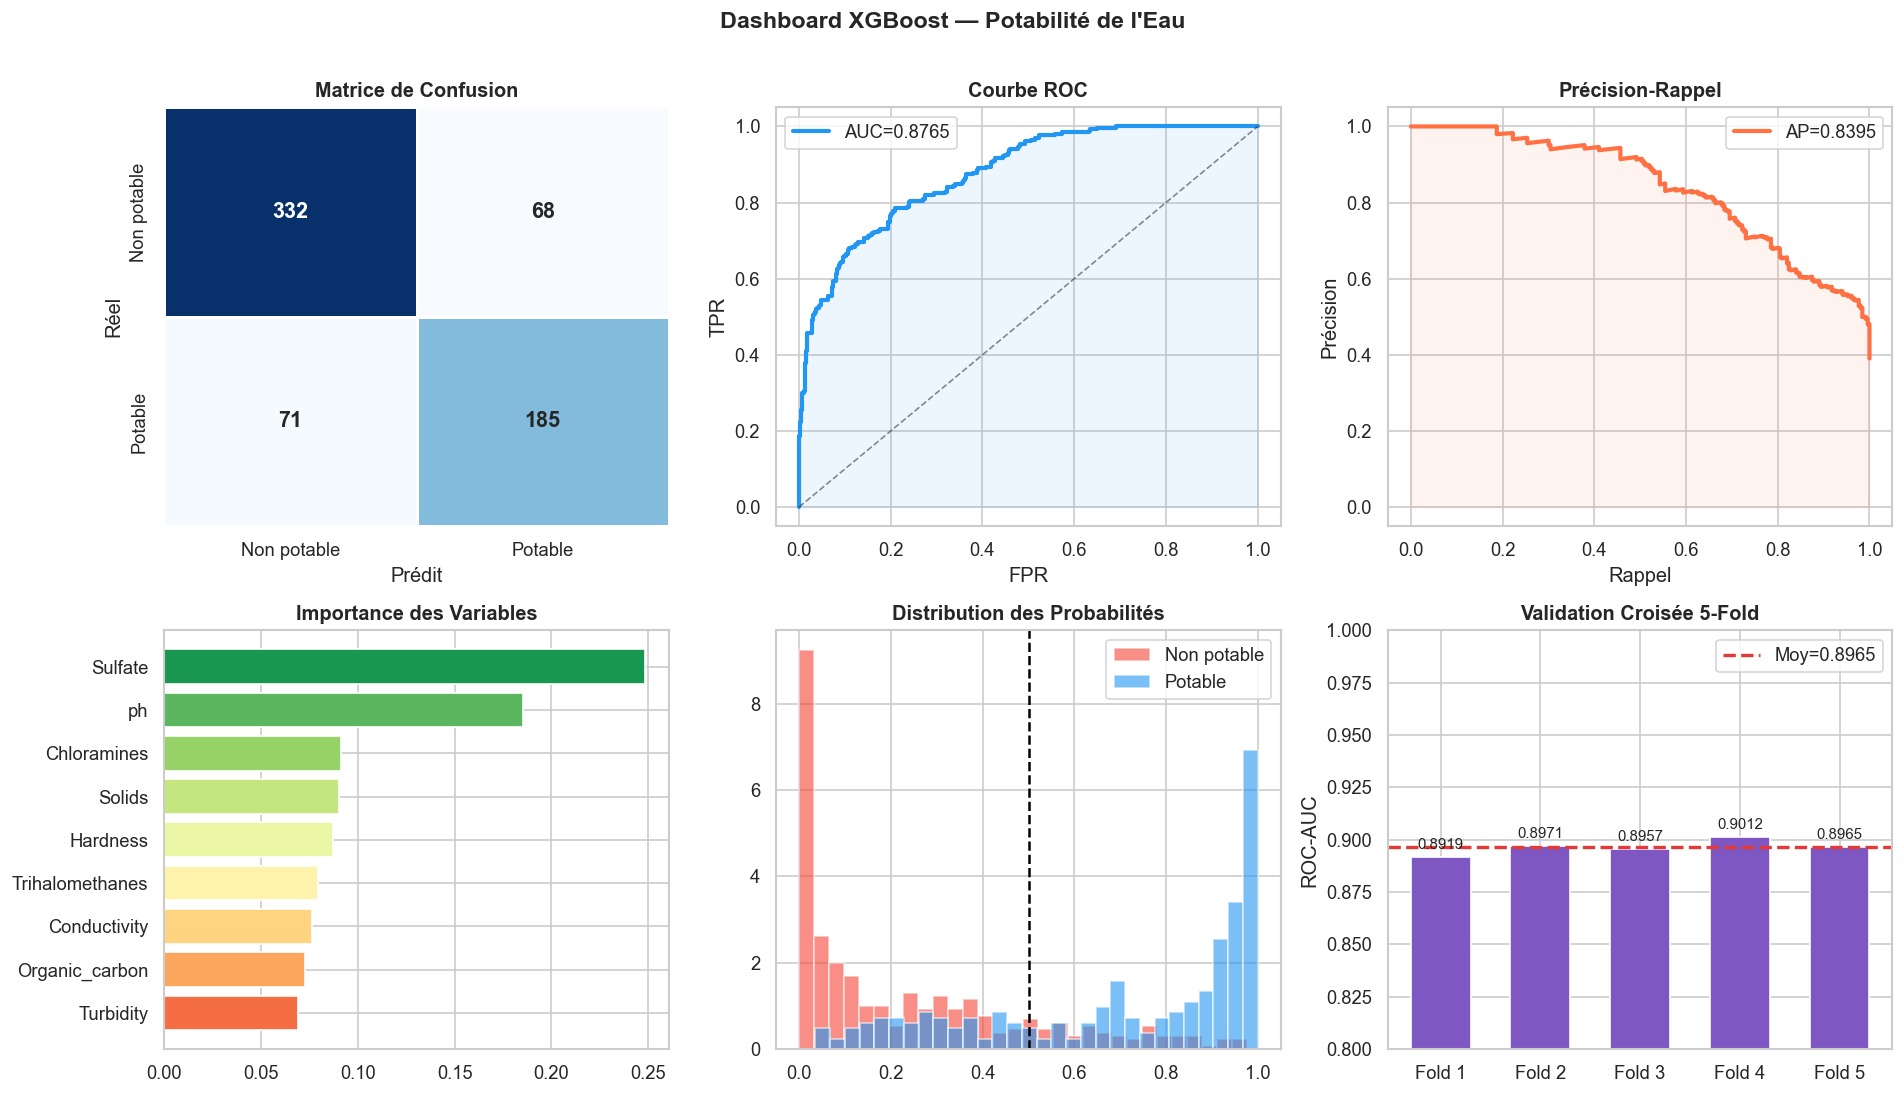

2026/05/21 10:20:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   Artefacts enregistrés (CSV, TXT, PNG)


Successfully registered model 'WaterQualityXGBoost'.
2026/05/21 10:21:02 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WaterQualityXGBoost, version 1
Created version '1' of model 'WaterQualityXGBoost'.


  Modele enregistre dans le Registry : WaterQualityXGBoost

 Run terminé avec succès
   → http://localhost:5000/#/experiments/1/runs/b7fa8fb53f08403cb0c97fdfe789d12a
🏃 View run XGBoost_SMOTE_RobustScaler_v1 at: http://localhost:5000/#/experiments/1/runs/b7fa8fb53f08403cb0c97fdfe789d12a
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:
# ════════════════════════════════════════════════════
#   DÉMARRAGE DU RUN MLFLOW
# ════════════════════════════════════════════════════
with mlflow.start_run(
    experiment_id = experiment_id,
    run_name      = "XGBoost_SMOTE_RobustScaler_v1"
) as run:

    run_id = run.info.run_id
    print(f"  Run démarré")
    print(f"   Run ID       : {run_id}")
    print(f"   Expérience   : {EXP_NAME} (id={experiment_id})")
    print()

    # ── 1. TAGS ──────────────────────────────────────
    mlflow.set_tags({
        "model_type"    : "XGBoostClassifier",
        "dataset"       : "water_potability.csv",
        "preprocessing" : "imputation_mediane + winsorisation_1pct99pct",
        "resampling"    : "SMOTE",
        "scaler"        : "RobustScaler",
        "split"         : "80_20_stratifie",
        "task"          : "binary_classification",
        "target"        : "Potability",
        "source_notebook": "water_xgboost.ipynb",
    })
    print("   Tags enregistrés")

    # ── 2. PARAMÈTRES ────────────────────────────────
    mlflow.log_params(xgb_params)
    mlflow.log_params({
        "n_train_raw"      : metadata["n_train_raw"],
        "n_train_smote"    : metadata["n_train_smote"],
        "n_val"            : metadata["n_val"],
        "n_features"       : len(features),
        "winsorize_limits" : "1pct_99pct",
        "imputation"       : "median_by_group",
    })
    print("   Paramètres enregistrés")

    # ── 3. MÉTRIQUES ─────────────────────────────────
    # Recalcul depuis les prédictions sauvegardées
    val_metrics = {
        "val_accuracy"    : accuracy_score(y_val, y_pred),
        "val_f1"          : f1_score(y_val, y_pred),
        "val_precision"   : precision_score(y_val, y_pred),
        "val_recall"      : recall_score(y_val, y_pred),
        "val_roc_auc"     : roc_auc_score(y_val, y_pred_prob),
        "val_pr_auc"      : average_precision_score(y_val, y_pred_prob),
    }
    mlflow.log_metrics(val_metrics)
    mlflow.log_metrics({
        "cv_roc_auc_mean" : cv_scores.mean(),
        "cv_roc_auc_std"  : cv_scores.std(),
        "cv_roc_auc_min"  : cv_scores.min(),
        "cv_roc_auc_max"  : cv_scores.max(),
    })
    print("   Métriques enregistrées")

    # ── 4. ARTEFACTS ─────────────────────────────────
    imp_df = pd.DataFrame({
        "feature"   : features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    imp_df.to_csv("feature_importance.csv", index=False)
    mlflow.log_artifact("feature_importance.csv", artifact_path="reports")

    report = classification_report(y_val, y_pred,
                target_names=["Non potable", "Potable"])
    with open("classification_report.txt", "w") as f:
        lines_out = ["RAPPORT DE CLASSIFICATION - VALIDATION SET"]
        lines_out += ["="*50]
        lines_out += [report]
        lines_out += ["METRIQUES DETAILLEES :"]
        for k, v in val_metrics.items():
            lines_out.append(f"  {k}: {v:.4f}")
        lines_out.append(f"  cv_roc_auc: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
        f.write(chr(10).join(lines_out))
    mlflow.log_artifact("classification_report.txt", artifact_path="reports")

    # Dashboard
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Non potable","Potable"],
                yticklabels=["Non potable","Potable"],
                linewidths=1.5, linecolor="white", cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    axes[0].set_title("Matrice de Confusion", fontweight="bold")
    axes[0].set_ylabel("Réel"); axes[0].set_xlabel("Prédit")
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    axes[1].plot(fpr, tpr, color=C_POS, lw=2.5,
                 label=f"AUC={val_metrics['val_roc_auc']:.4f}")
    axes[1].plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=C_POS)
    axes[1].set_title("Courbe ROC", fontweight="bold")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()
    prec_c, rec_c, _ = precision_recall_curve(y_val, y_pred_prob)
    axes[2].plot(rec_c, prec_c, color="#FF7043", lw=2.5,
                 label=f"AP={val_metrics['val_pr_auc']:.4f}")
    axes[2].fill_between(rec_c, prec_c, alpha=0.08, color="#FF7043")
    axes[2].set_title("Précision-Rappel", fontweight="bold")
    axes[2].set_xlabel("Rappel"); axes[2].set_ylabel("Précision"); axes[2].legend()
    imp_sorted = imp_df.sort_values("importance")
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(features)))
    axes[3].barh(imp_sorted["feature"], imp_sorted["importance"],
                 color=colors_fi, edgecolor="white")
    axes[3].set_title("Importance des Variables", fontweight="bold")
    for lbl, color, name in [(0, C_NEG, "Non potable"),(1, C_POS, "Potable")]:
        mask = y_val == lbl
        axes[4].hist(y_pred_prob[mask], bins=30, alpha=0.6,
                     color=color, label=name, density=True)
    axes[4].axvline(0.5, color="black", linestyle="--", lw=1.5)
    axes[4].set_title("Distribution des Probabilités", fontweight="bold")
    axes[4].legend()
    folds = [f"Fold {i+1}" for i in range(len(cv_scores))]
    bars  = axes[5].bar(folds, cv_scores, color="#7E57C2", edgecolor="white", width=0.6)
    axes[5].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    axes[5].axhline(cv_scores.mean(), color="#E53935", linestyle="--", lw=2,
                    label=f"Moy={cv_scores.mean():.4f}")
    axes[5].set_ylim(0.8, 1.0)
    axes[5].set_title("Validation Croisée 5-Fold", fontweight="bold")
    axes[5].set_ylabel("ROC-AUC"); axes[5].legend()
    plt.suptitle("Dashboard XGBoost — Potabilité de l'Eau",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("dashboard_xgboost.png", bbox_inches="tight", dpi=150)
    plt.show()
    mlflow.log_artifact("dashboard_xgboost.png", artifact_path="figures")
    print("   Artefacts enregistrés (CSV, TXT, PNG)")

    # ── 5. ENREGISTREMENT DU MODÈLE ──────────────────
    mlflow.xgboost.log_model(
        model,
        artifact_path         = "xgboost_model",
        registered_model_name = MODEL_NAME,
        input_example         = pd.DataFrame(X_val_sc[:3], columns=features),
    )
    print(f"  Modele enregistre dans le Registry : {MODEL_NAME}")
    print()
    print(f" Run terminé avec succès")
    print(f"   → http://localhost:{MLFLOW_PORT}/#/experiments/{experiment_id}/runs/{run_id}")


---
## 6. Consultation des Résultats via MLflow

In [25]:
# ── Récupération complète du run ──
run_data = client.get_run(run_id)

print('╔══════════════════════════════════════════════════════╗')
print('║           RÉSUMÉ DU RUN — MLflow                    ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Run ID       : {run_id[:20]}...              ║')
print(f'║  Expérience   : {EXP_NAME}   ║')
print(f'║  Statut       : {run_data.info.status}                              ║')
print('╠══════════════════════════════════════════════════════╣')
print('║      MÉTRIQUES DE VALIDATION :                       ║')
for k, v in run_data.data.metrics.items():
    print(f'║    {k:28s} : {v:.4f}          ║')
print('╠══════════════════════════════════════════════════════╣')
print('║      HYPERPARAMÈTRES PRINCIPAUX :                    ║')
key_params = ['n_estimators','max_depth','learning_rate','subsample',
              'colsample_bytree','reg_alpha','reg_lambda']
for k in key_params:
    v = run_data.data.params.get(k, 'N/A')
    print(f'║    {k:28s} : {v:<20s}      ║')
print('╠══════════════════════════════════════════════════════╣')
print('║      TAGS :                                          ║')
for k, v in run_data.data.tags.items():
    if not k.startswith('mlflow.'):
        print(f'║    {k:28s} : {str(v):<20s}      ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║           RÉSUMÉ DU RUN — MLflow                    ║
╠══════════════════════════════════════════════════════╣
║  Run ID       : b7fa8fb53f08403cb0c9...              ║
║  Expérience   : experiment_water_quality   ║
║  Statut       : FINISHED                              ║
╠══════════════════════════════════════════════════════╣
║      MÉTRIQUES DE VALIDATION :                       ║
║    val_accuracy                 : 0.7881          ║
║    val_f1                       : 0.7269          ║
║    val_precision                : 0.7312          ║
║    val_recall                   : 0.7227          ║
║    val_roc_auc                  : 0.8765          ║
║    val_pr_auc                   : 0.8395          ║
║    cv_roc_auc_mean              : 0.8965          ║
║    cv_roc_auc_std               : 0.0030          ║
║    cv_roc_auc_min               : 0.8919          ║
║    cv_roc_auc_max               : 0.9012          ║
╠═════════════

In [26]:
# ── Versions du modèle dans le Registry ──
print(f'\n Model Registry — "{MODEL_NAME}" :')
try:
    versions = client.search_model_versions(f"name='{MODEL_NAME}'")
    for v in versions:
        print(f'  Version {v.version}')
        print(f'    Status  : {v.status}')
        print(f'    Run ID  : {v.run_id[:20]}...')
        print(f'    Source  : {v.source}')
except Exception as e:
    print(f'  Info registry : {e}')

print(f'\n Interface MLflow disponible sur :')
print(f'   http://localhost:{MLFLOW_PORT}')
print(f'   → Onglet "Experiments" : {EXP_NAME}')
print(f'   → Onglet "Models"      : {MODEL_NAME}')


 Model Registry — "WaterQualityXGBoost" :
  Version 1
    Status  : READY
    Run ID  : b7fa8fb53f08403cb0c9...
    Source  : models:/m-d748cc25e3a14eafbb357be2183de74d

 Interface MLflow disponible sur :
   http://localhost:5000
   → Onglet "Experiments" : experiment_water_quality
   → Onglet "Models"      : WaterQualityXGBoost


In [27]:
# ── Chargement et inférence depuis le Registry ──
model_uri    = f'runs:/{run_id}/xgboost_model'
loaded_model = mlflow.xgboost.load_model(model_uri)

sample       = pd.DataFrame(X_val_sc[:5], columns=features)
predictions  = loaded_model.predict(X_val_sc[:5])
probabilities= loaded_model.predict_proba(X_val_sc[:5])[:,1]

print(' Inférence depuis le modèle chargé via MLflow :')
result = sample.copy()
result['Potability_réelle']  = y_val.values[:5]
result['Potability_prédite'] = predictions
result['Proba_potable']      = probabilities.round(4)
result[['Potability_réelle','Potability_prédite','Proba_potable']]

 Inférence depuis le modèle chargé via MLflow :


,Potability_réelle,Potability_prédite,Proba_potable
0,1,1,0.9907
1,0,0,0.0329
2,0,0,0.0148
3,0,0,0.2434
4,0,0,0.0873


In [28]:
# ── Arrêt propre du serveur ──
# Décommenter pour stopper le serveur en fin de session
# mlflow_server.terminate()
# print(' Serveur MLflow arrêté')
print('  Serveur MLflow toujours actif sur http://localhost:5000')
print('   Pour l\'arrêter : mlflow_server.terminate()')

  Serveur MLflow toujours actif sur http://localhost:5000
   Pour l'arrêter : mlflow_server.terminate()
